In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from pandas.api.types import is_numeric_dtype
import seaborn as sns

import importlib
import config
importlib.reload(config)

from config import demographics, vitalsign_vars, lab_vars,treatment_vars,vent_vars,other_vent_vars
from config import all_demographics, all_vitalsign_vars, all_lab_vars, all_treatment_vars, all_vent_vars, all_other_vent_vars
from config import all_identifiers
from config import ffill_windows_clinical
from config import limit

from missforest import MissForest
from lightgbm import LGBMRegressor
from sklearn.impute import KNNImputer

import warnings
warnings.filterwarnings('ignore')

# Exploratory Data Analysis

In [2]:
data= pd.read_csv('dati.csv', low_memory=False, parse_dates=['dod','admittime', 'dischtime', 'icu_intime',
       'icu_outtime', 'icu_day_start', 'intubation_time', 'extubation_time', 'tracheo_ts', 'end_mech_vent','next_intubation_time' ])
data.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'gender', 'age', 'dod', 'admittime',
       'admission_type', 'dischtime', 'los_hospital_day', 'hospmort',
       'hospmort28day', 'hospmort90day', 'icumort', 'icu_intime',
       'icu_outtime', 'los_icu_day', 'weight', 'height', 'bmi', 'comorb_score',
       'icu_day_start', 'ph', 'paco2', 'pao2', 'lactate', 'hemoglobin',
       'albumin', 'platelet', 'wbc', 'bilirubin', 'creatinine', 'bun',
       'sodium', 'potassium', 'bicarbonate', 'uo', 'rate_dobutamine',
       'rate_dopamine', 'rate_epinephrine', 'rate_norepinephrine',
       'rate_vasopressin', 'prone_24h', 'crrt_24h', 'ino_24h', 'diuretic_24h',
       'steroid_24h', 'transfusion_24h', 'transfusion_type', 'neuroblock',
       'opioids', 'is_sedated', 'sedation_type', 'infection_at_icu_admission',
       'site_of_infection', 'admission_category', 'ards', 'septic_shock',
       'gcs', 'heartrate', 'sysbp', 'diasbp', 'meanbp', 'resprate', 'tempc',
       'spo2', 'shock_index', 'tidal_vol

### Added feature _weaning_success_

Weaning is defined as an attempt of extubation that results in a successful outcome.\
In our case, we define:
* Success (1): if there is only one mechanical ventilation event, or if the time between two consecutive events is greater than or equal to 72 hours.
* Failure (0): if the time between two consecutive ventilation events is less than 72 hours.

In [3]:
data['weaning_success']=np.where(data['next_intubation_time'].isna() | (data['time_no_mech_vent'] >= 72), 1, 0)
data.head()

,subject_id,hadm_id,stay_id,gender,age,dod,admittime,admission_type,dischtime,los_hospital_day,...,is_tracheo,tracheo_ts,end_mech_vent,time_no_mech_vent,next_intubation_time,sofa,percentual_missing_value_sofa,sapsii,percentual_missing_value_sapsii,weaning_success
0,10001884,26184834,37510196,F,77,2131-01-20,2131-01-07 20:39:00,postSurgical,2131-01-20 05:15:00,12.36,...,NaN,NaT,NaT,NaN,NaT,10,0,73,0,1
1,10001884,26184834,37510196,F,77,2131-01-20,2131-01-07 20:39:00,postSurgical,2131-01-20 05:15:00,12.36,...,NaN,NaT,NaT,NaN,NaT,10,0,73,0,1
2,10001884,26184834,37510196,F,77,2131-01-20,2131-01-07 20:39:00,postSurgical,2131-01-20 05:15:00,12.36,...,NaN,NaT,NaT,NaN,NaT,10,0,73,0,1
3,10001884,26184834,37510196,F,77,2131-01-20,2131-01-07 20:39:00,postSurgical,2131-01-20 05:15:00,12.36,...,NaN,NaT,NaT,NaN,NaT,10,0,73,0,1
4,10001884,26184834,37510196,F,77,2131-01-20,2131-01-07 20:39:00,postSurgical,2131-01-20 05:15:00,12.36,...,NaN,NaT,NaT,NaN,NaT,10,0,73,0,1


In [4]:
print(f"The dataset includes {data['subject_id'].nunique()} patients and a total of {data.shape[0]} rows and {data.shape[1]} columns.")

The dataset includes 16061 patients and a total of 621707 rows and 86 columns.


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 621707 entries, 0 to 621706
Data columns (total 86 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   subject_id                       621707 non-null  int64         
 1   hadm_id                          621707 non-null  int64         
 2   stay_id                          621707 non-null  int64         
 3   gender                           621707 non-null  object        
 4   age                              621707 non-null  int64         
 5   dod                              246285 non-null  datetime64[ns]
 6   admittime                        621707 non-null  datetime64[ns]
 7   admission_type                   621707 non-null  object        
 8   dischtime                        621707 non-null  datetime64[ns]
 9   los_hospital_day                 621707 non-null  float64       
 10  hospmort                         621707 non-

### Choosing Appropriate Time Windows Before and After Ventilation

By extracting the data, 4-hour intervals were created starting from the ICU admission. For the purposes of the thesis and following the article by [Peine](https://www.nature.com/articles/s41746-021-00388-6), we need the first 72 h of the ventilation events.

In [4]:
# Conta 0 prima del primo 1
def count_zeros_before_first_one(series):
    try:
        idx = series.idxmax()
        return (series.loc[:idx-1] == 0).sum()
    except:
        return 0

# Conta 0 dopo l'ultimo 1
def count_zeros_after_last_one(series):
    try:
        idx = series[::-1].idxmax()
        last_idx = series.index.get_loc(idx)
        return (series.iloc[last_idx+1:] == 0).sum()
    except:
        return 0
    
result = data.groupby('subject_id')['is_intubated'].agg(
    count_0_before_1 = count_zeros_before_first_one,
    count_0_after_1  = count_zeros_after_last_one
).reset_index()

In [5]:
def filtra_blocco(gruppo, pre=2, post=18):
    one_indices = gruppo[gruppo['is_intubated'] == 1].index

    if one_indices.empty:
        return pd.DataFrame()  # Se non ci sono 1, ritorna vuoto

    primo_1 = one_indices.min()
    ultimo_1 = one_indices.max()

    # Range di righe da includere
    start_idx = max(primo_1 - pre, gruppo.index.min())
    end_idx   = min(ultimo_1 + post, gruppo.index.max())

    return gruppo.loc[start_idx:end_idx]

# Applica la funzione per ogni soggetto
df_filtrato = data.groupby('subject_id', group_keys=False).apply(filtra_blocco)

# Reset index se vuoi un DataFrame pulito
df_filtrato = df_filtrato.reset_index(drop=True)
df_filtrato

,subject_id,hadm_id,stay_id,gender,age,dod,admittime,admission_type,dischtime,los_hospital_day,...,is_tracheo,tracheo_ts,end_mech_vent,time_no_mech_vent,next_intubation_time,sofa,percentual_missing_value_sofa,sapsii,percentual_missing_value_sapsii,weaning_success
0,10001884,26184834,37510196,F,77,2131-01-20,2131-01-07 20:39:00,postSurgical,2131-01-20 05:15:00,12.36,...,NaN,NaT,NaT,NaN,NaT,10,0,73,0,1
1,10001884,26184834,37510196,F,77,2131-01-20,2131-01-07 20:39:00,postSurgical,2131-01-20 05:15:00,12.36,...,NaN,NaT,NaT,NaN,NaT,10,0,73,0,1
2,10001884,26184834,37510196,F,77,2131-01-20,2131-01-07 20:39:00,postSurgical,2131-01-20 05:15:00,12.36,...,0.0,NaT,2131-01-19 18:40:00,NaN,NaT,11,16,73,0,1
3,10001884,26184834,37510196,F,77,2131-01-20,2131-01-07 20:39:00,postSurgical,2131-01-20 05:15:00,12.36,...,0.0,NaT,2131-01-19 18:40:00,NaN,NaT,11,16,73,0,1
4,10001884,26184834,37510196,F,77,2131-01-20,2131-01-07 20:39:00,postSurgical,2131-01-20 05:15:00,12.36,...,0.0,NaT,2131-01-19 18:40:00,NaN,NaT,11,16,73,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536295,19999987,23865745,36195440,F,58,NaT,2145-11-02 21:38:00,postSurgical,2145-11-11 12:57:00,8.64,...,NaN,NaT,NaT,NaN,NaT,8,16,52,0,1
536296,19999987,23865745,36195440,F,58,NaT,2145-11-02 21:38:00,postSurgical,2145-11-11 12:57:00,8.64,...,NaN,NaT,NaT,NaN,NaT,8,16,52,0,1
536297,19999987,23865745,36195440,F,58,NaT,2145-11-02 21:38:00,postSurgical,2145-11-11 12:57:00,8.64,...,NaN,NaT,NaT,NaN,NaT,8,16,52,0,1
536298,19999987,23865745,36195440,F,58,NaT,2145-11-02 21:38:00,postSurgical,2145-11-11 12:57:00,8.64,...,NaN,NaT,NaT,NaN,NaT,8,16,52,0,1


In [8]:
print(f"The dataset includes {df_filtrato['subject_id'].nunique()} patients and a total of {df_filtrato.shape[0]} rows and {df_filtrato.shape[1]} columns.")

The dataset includes 16061 patients and a total of 536300 rows and 86 columns.


### Salvataggio dei dati (da non ricompilare)

In [2]:
df_filtrato.to_csv('dati_temporali_corretto.csv', index=False)

NameError: name 'df_filtrato' is not defined

## Rate between features e samples
In some datasets there are **more** features than samples. This can introduce problems such as particularly strong overfitting of the model to the datasets.\
So before anything else, we check if the datasets have a rate of features and samples greater than one.

In [3]:
data= pd.read_csv('dati_temporali_corretto.csv')
data.head()

,subject_id,hadm_id,stay_id,gender,age,dod,admittime,admission_type,dischtime,los_hospital_day,...,is_tracheo,tracheo_ts,end_mech_vent,time_no_mech_vent,next_intubation_time,sofa,percentual_missing_value_sofa,sapsii,percentual_missing_value_sapsii,weaning_success
0,10001884,26184834,37510196,F,77,2131-01-20,2131-01-07 20:39:00,postSurgical,2131-01-20 05:15:00,12.36,...,NaN,NaN,NaN,NaN,NaN,10,0,73,0,1
1,10001884,26184834,37510196,F,77,2131-01-20,2131-01-07 20:39:00,postSurgical,2131-01-20 05:15:00,12.36,...,NaN,NaN,NaN,NaN,NaN,10,0,73,0,1
2,10001884,26184834,37510196,F,77,2131-01-20,2131-01-07 20:39:00,postSurgical,2131-01-20 05:15:00,12.36,...,0.0,NaN,2131-01-19 18:40:00,NaN,NaN,11,16,73,0,1
3,10001884,26184834,37510196,F,77,2131-01-20,2131-01-07 20:39:00,postSurgical,2131-01-20 05:15:00,12.36,...,0.0,NaN,2131-01-19 18:40:00,NaN,NaN,11,16,73,0,1
4,10001884,26184834,37510196,F,77,2131-01-20,2131-01-07 20:39:00,postSurgical,2131-01-20 05:15:00,12.36,...,0.0,NaN,2131-01-19 18:40:00,NaN,NaN,11,16,73,0,1


In [7]:
print(f"The rate between features and samples data is: {round(data.shape[0]/data.shape[1],2)}")

The rate between features and samples data is: 6236.05


This does not apply to our dataset.

## Nan detection
Another bane of machine learning is the presense of NaN values within the dataset. A limited amount of NaN values, when it is not clustered in a single sample or feature, can be patched up with an imputation procedure.\
But if we find a considerable amount of NaNs in a single sample or feature we might have to drop the feature or sample interested.

In [2]:
def print_missing_pct(dataframe, variables):
    """
    Formatted print of the number of NaNs in `dataframe` for each variable in `variables`.
    """
    ljust = max(map(len, variables))
    for var in variables:
        if round(dataframe[var].isna().mean()*100,2)>0:
            print('{} {} % \t ({})'.format(var.ljust(ljust), round(dataframe[var].isna().mean()*100,2), dataframe[var].isna().sum() ))
        else: 
            print('{} {} %'.format(var.ljust(ljust), round(dataframe[var].isna().mean()*100,2)))

First, let's verify that all the identifying parameters and timestamps do not contain any null values.

In [13]:
print_missing_pct(data, all_identifiers)

subject_id 0.0 %
hadm_id    0.0 %
stay_id    0.0 %


In [14]:
var='icu_day_start'
print(f"{var} {round(data[var].isna().mean()*100,2)} % ")

icu_day_start 0.0 % 


### Demographics variables

Let's examine the demographic variables for each patient in the dataset.

In [ ]:
patients = data.drop_duplicates(all_identifiers, keep='first')
print_missing_pct(patients, all_demographics)

gender             0.0 %
age                0.0 %
dod                66.11 % 	 (10618)
admittime          0.0 %
admission_type     0.0 %
admission_category 0.02 % 	 (3)
dischtime          0.0 %
los_hospital_day   0.0 %
hospmort           0.0 %
hospmort28day      0.0 %
hospmort90day      0.0 %
icumort            0.0 %
icu_intime         0.0 %
icu_outtime        0.0 %
los_icu_day        0.0 %
weight             1.34 % 	 (216)
height             18.19 % 	 (2921)
bmi                18.52 % 	 (2974)
comorb_score       0.0 %


In [16]:
patients[patients['admission_category'].isna()]['admission_type']

230569    postSurgical 
387201    postSurgical 
455648    postSurgical 
Name: admission_type, dtype: object

The values are all present except for the following:
* **dod (Date Of Death)**: A missing value means that the patient is not deceased. We will remove this field as we have the flags _hospmort_, _icumort_, _hospmort28day_, _hospmort90day_  which indicate whether the patient is alive (1) or deceased (0) in the ICU or in the hospital, or after 28/90 days.
* **admission_category**: This specifies the type of admission. There are 3 patients with missing values. Upon reviewing the admission_category values, I find that they are classified as 'Post Surgical,' so I will impute the missing values with 'Postoperative Monitoring.'
* **weight**: Weight (kg). This data is redundant with BMI and will be removed.
* **height**: Height (cm). This data is redundant with BMI and will be removed.
* **bmi**: Body Mass Index, expressed as $$ BMI = \frac{weight}{height^2} * 100 \quad [\frac{\text{kg}}{\text{m}^2}] $$ The weight and height are used to calculate BMI, making them redundant. We will remove these fields. For BMI, we will impute the missing values using MissForest.

### Vital Sign

In [17]:
print_missing_pct(data, all_vitalsign_vars)

sofa                            0.0 %
percentual_missing_value_sofa   0.0 %
sapsii                          0.0 %
percentual_missing_value_sapsii 0.0 %
ards                            0.01 % 	 (57)
septic_shock                    0.01 % 	 (57)
gcs                             16.85 % 	 (90385)
heartrate                       1.65 % 	 (8872)
sysbp                           1.91 % 	 (10244)
diasbp                          1.91 % 	 (10261)
meanbp                          1.91 % 	 (10236)
resprate                        1.81 % 	 (9733)
tempc                           12.19 % 	 (65394)
spo2                            2.01 % 	 (10771)
shock_index                     1.95 % 	 (10451)


We will impute the missing data using the specified time windows. In this case, almost all the missing values have a validity of 48 hours, except for ARDS and the various shock indices, which have a validity equal to the duration of the hospitalization.

In [18]:
data[data['septic_shock'].isna()]['subject_id'].unique() , data[data['ards'].isna()]['subject_id'].unique()

(array([14349469, 17225329, 18536401], dtype=int64),
 array([14349469, 17225329, 18536401], dtype=int64))

We can observe that the individuals with both ARDS and septic shock missing values overlap and are only 3 cases; it should be evaluated whether to remove them or impute the missing data.

### LabValues

In [19]:
print_missing_pct(data, all_lab_vars)

ph            67.4 % 	 (361471)
paco2         68.73 % 	 (368604)
pao2          68.72 % 	 (368558)
lactate       82.22 % 	 (440940)
hemoglobin    72.45 % 	 (388568)
albumin       95.93 % 	 (514479)
platelet      74.19 % 	 (397878)
wbc           74.65 % 	 (400337)
bilirubin     91.71 % 	 (491818)
creatinine    70.59 % 	 (378549)
bun           70.64 % 	 (378834)
sodium        66.53 % 	 (356797)
potassium     62.06 % 	 (332843)
bicarbonate   70.54 % 	 (378287)
pao2fio2ratio 73.38 % 	 (393513)


In this case, we have missing data with a very high percentage, but even in this case, the validity is 48 hours. We will recalculate after the imputation is performed.\
However, two parameters, albumin and bilirubin, stand out because they have more than 90% of their data missing.\
Another relevant parameter is the PaO₂/FiO₂ ratio. This parameter will be recalculated once we have imputed the FiO₂ and PaO₂ data. The value is calculated as:
$$ \text{PaO}_2/\text{FiO}_2 = \frac{\text{PaO}_2\ (\text{mmHg})}{\text{FiO}_2\ (\%) / 100} $$
The values of pao2fio2ratio and shock_index were recomputed after the imputation.

### Treatments

In [20]:
print_missing_pct(data,all_treatment_vars)

uo                         14.89 % 	 (79869)
rate_dobutamine            99.66 % 	 (534450)
rate_dopamine              99.51 % 	 (533690)
rate_epinephrine           98.5 % 	 (528270)
rate_norepinephrine        87.68 % 	 (470238)
rate_vasopressin           97.78 % 	 (524412)
prone_24h                  0.0 %
crrt_24h                   0.0 %
ino_24h                    0.0 %
diuretic_24h               0.0 %
steroid_24h                0.0 %
transfusion_24h            0.0 %
transfusion_type           38.74 % 	 (207763)
neuroblock                 0.0 %
opioids                    0.0 %
is_sedated                 0.0 %
sedation_type              70.6 % 	 (378650)
infection_at_icu_admission 0.0 %
site_of_infection          17.08 % 	 (91594)


In [9]:
flag=['transfusion_24h','is_sedated','infection_at_icu_admission']
cat = ['transfusion_type','sedation_type','site_of_infection']
for i in range(3):
    a = data[[flag[i], cat[i]]] 
    l = len(a[(a[flag[i]]==1) & (a[cat[i]].isna())])
    print(f"In the {flag[i]} flag, there is {l} instances of missing data when the flag equals 1,\
            \n\t\t and {len(a[(a[flag[i]]==0) & (a[cat[i]].isna())])} instances when the flag equals 0.")

In the transfusion_24h flag, there is 0 instances of missing data when the flag equals 1,            
		 and 207763 instances when the flag equals 0.
In the is_sedated flag, there is 23826 instances of missing data when the flag equals 1,            
		 and 354824 instances when the flag equals 0.
In the infection_at_icu_admission flag, there is 0 instances of missing data when the flag equals 1,            
		 and 91594 instances when the flag equals 0.


The missing values for the vasopressors (_dobutamine, dopamine, epinephrine, norepinephrine, vasopressin_) could indicate either a missing value or a dosage of zero. As for vasopressors, the rate was replaced by a binary flag _vasopressors_ indicating whether the drug was administered or not.\
Other variables that emerge include _transfusion_type, sedation_type_ and _site_of_infection_ all of which are categorical variables.\
A missing value in the presence of a flag (_transfusion_24h, is_sedated, infection_at_icu_admission_) set to 0 means that the value does not exist, so the missing values are replaced with a category labeled 'none'. In cases where the flag is set to 1 (such as _is_sedated_), we impute the missing values with the worst-case scenario: 'Propofol', alternatively, if a recorded value exists, it will be repeated.

### Ventilation Variables

In [22]:
print_missing_pct(data, all_vent_vars)

peep         39.79 % 	 (213367)
fio2         31.82 % 	 (170657)
tidal_volume 40.06 % 	 (214863)


In [23]:
print_missing_pct(data, all_other_vent_vars)

vent_mode            39.66 % 	 (212676)
vent_type            41.56 % 	 (222874)
is_intubated         0.0 %
intubation_time      32.17 % 	 (172548)
extubation_time      32.17 % 	 (172548)
is_tracheo           32.17 % 	 (172548)
tracheo_ts           96.18 % 	 (515795)
end_mech_vent        32.17 % 	 (172548)
time_no_mech_vent    91.66 % 	 (491594)
next_intubation_time 91.66 % 	 (491594)
weaning_success      0.0 %


The values _peep, fio2_ and _tidal_volume_ are missing due to the fact that mechanical ventilation was not applied.\
The same reasoning applies to the other missing values.

## Function

In [3]:
all_vars= vitalsign_vars + lab_vars + treatment_vars + vent_vars + other_vent_vars

# Fill missing data
We proceed with the handling of missing data.\
First, we will impute the missing values with the constant value and then we will using the SAH (sample and hold) windowing technique, applying the valid time windows specified for each parameter.

We expect that an error occurs since sedation_type has missing values when the flag is set to 1. So, when we impute the data we will take care of this problem.

In [2]:
data= pd.read_csv('dati_temporali_corretto.csv')
data['ibw'] = data.apply(lambda row: 50 + 0.91 * (row['height'] - 152.4) if row['gender'] == 'M' else 45 + 0.91 * (row['height'] - 152.4), axis=1)
flag=['transfusion_24h','is_sedated','infection_at_icu_admission']
cat = ['transfusion_type','sedation_type','site_of_infection']

In [3]:
data['admission_category']=data['admission_category'].fillna('Monitoraggio postoperatorio')
for i in range(3):
    data.loc[(data[flag[i]] == 0) & (data[cat[i]].isna()), cat[i]] = 'None'
    if flag[i]=="is_sedated":
        data.loc[data[flag[i]] == 1, cat[i]] = data.loc[data['is_sedated'] == 1, 'sedation_type'].ffill()

# Let's check that the filling was successful
assert(round(data['admission_category'].isna().mean()*100,2)==0), 'Admission category feature has a missing values'
assert all(data[var].isna().mean()==0 for var in cat), 'Some features have a missing values'

We replace each vaso_cols with a single column that contains 1 if any vasopressor is present, and 0 otherwise.

In [4]:
vaso_cols = [
    'rate_dobutamine', 
    'rate_dopamine', 
    'rate_epinephrine', 
    'rate_norepinephrine', 
    'rate_vasopressin'
]
for col in vaso_cols:
    data[f'{col.replace("rate_", "has_")}'] = (data[col] > 0).astype(int)
    assert(data[f'{col.replace("rate_", "has_")}'].isna().mean()==0)

We remove all the not usefull columns.

In [5]:
all_group = demographics + vitalsign_vars + lab_vars + treatment_vars + vent_vars  + other_vent_vars
all_vars = all_demographics + all_vitalsign_vars + all_lab_vars + all_treatment_vars + all_vent_vars  + all_other_vent_vars
col_to_remove=[x for x in all_vars if x not in all_group]  + ['hadm_id', 'stay_id']
print(data.shape)
data.drop(col_to_remove, axis=1, inplace=True)
data.shape

(536300, 92)


(536300, 71)

These are the patients who are ventilated and have missing values for vent_type and vent_mode. Since it is rare for the ventilation machine or mode to change within a 4-hour window, it was decided to fill the missing data by carrying forward the existing modes.

In [6]:
mask_1= (data['is_intubated'] == 1)
data.loc[mask_1,'vent_type'].unique()

array(['Hamilton', nan, 'Drager', 'Avea', 'Other', 'PB 7200',
       'Sensor Medic (HFO)', 'BiPAP/CPAP'], dtype=object)

In [7]:
print(data.loc[mask_1, 'vent_type'].isna().mean())
mask_1= (data['is_intubated'] == 1)

data.loc[mask_1, 'vent_type'] = ( data.loc[mask_1].groupby('subject_id')['vent_type'].transform(lambda x: x.ffill().bfill()))

print(data.loc[mask_1, 'vent_type'].isna().mean())
assert data.loc[mask_1, 'vent_type'].isna().mean() == 0, "Not all the missing data are filling."

0.15653755043382264
0.0005759831948432563


AssertionError: Not all the missing data are filling.

In [8]:
print(f"There are {len(data[(data['vent_type'].isna()) & (data['is_intubated']==1)]['subject_id'].unique())} patients without 'vent_type'.")

tot = 0
for i in data[(data['vent_type'].isna()) & (data['is_intubated']==1)]['subject_id'].unique():
    count = data[(data['subject_id']==i) & (data['vent_type'].notna())]['vent_type'].shape[0]
    if count>0:
        tot +=1       
        arr = data[(data['subject_id']==i) & (data['vent_type'].notna())]['vent_type'].values
        assert np.all(arr == arr[0]), f'The patient {i} do not have all equal values'
        data.loc[ mask_1 & (data['subject_id'] == i), 'vent_type'] = data.loc[mask_1 & (data['subject_id'] == i),'vent_type'].fillna(arr[0])

print(f"After checking all the cases of intubation, there are {len(data[(data['vent_type'].isna()) & (data['is_intubated']==1)]['subject_id'].unique())} without any information about the 'vent_type'.")

There are 81 patients without 'vent_type'.
After checking all the cases of intubation, there are 50 without any information about the 'vent_type'.


To fill in the missing values, I will perform a frequency analysis to identify, for each ventilation mode, which ventilator type is most frequently used.

In [9]:
ct = pd.crosstab(data.loc[mask_1, 'vent_mode'], data.loc[mask_1,'vent_type'])

for i in data[(data['vent_type'].isna()) & (data['is_intubated']==1)]['subject_id'].unique():
    val = data.loc[ mask_1 & (data['subject_id'] == i), 'vent_mode'].mode().iloc[0]
    data.loc[ mask_1 & (data['subject_id'] == i), 'vent_type'] =data.loc[mask_1 & (data['subject_id'] == i),'vent_type'].fillna( ct.loc[val].dropna().idxmax() ) 
assert data.loc[mask_1, 'vent_type'].isna().mean() == 0, "Not all the missing data are filling."

In the case of vent_mode, the label Standby and Ambient were removed for intubated patients, as they represented an error introduced during data aggregation. Subsequently, missing values were filled using existing ventilation modes.

In [10]:
mask_vent =  (data['is_intubated']==1)
mask_standby = (data['vent_mode']=='Standby')
mask_ambient = (data['vent_mode']=='Ambient')
data.loc[mask_vent & mask_standby & mask_ambient, 'vent_mode'] = np.nan
data.loc[mask_vent, 'vent_mode'] = data.loc[mask_vent, 'vent_mode'].ffill().bfill()

assert data.loc[mask_vent, 'vent_mode'].isna().mean()==0

Let’s proceed with the data for patients labeled as non-ventilated.

In [11]:
mask = data['vent_type'].isna() & data['vent_mode'].notna()

while mask.any():
    for idx, row in data.loc[mask].iterrows():
        subject_id = row['subject_id']

        patient_types = data.loc[
            (data['subject_id'] == subject_id) & data['vent_type'].notna(),
            'vent_type'
        ]

        if not patient_types.empty:
            most_common = patient_types.mode().iloc[0]
            data.at[idx, 'vent_type'] = most_common
    
    mask = data['vent_type'].isna() & data['vent_mode'].notna()

assert len(data[mask]) == 0


In [12]:
def set_none_if_both_nan_at_start(group):
    found_value = False
    
    for i, row in group.iterrows():
        if found_value:
            break

        if pd.isna(row['vent_type']) and pd.isna(row['vent_mode']):
            group.at[i, 'vent_type'] = 'None'
            group.at[i, 'vent_mode'] = 'None'
        else:
            if (not pd.isna(row['vent_type'])) or (not pd.isna(row['vent_mode'])):
                found_value = True
    
    return group

def set_none_after_last_valid(group):
    # Assumiamo group ordinato per tempo crescente
    group = group.copy()
    
    # Trova indice ultima riga con vent_type non null
    not_null_indices = group.index[~group['vent_type'].isna()]
    if len(not_null_indices) == 0:
        # Nessun valore valido: opzionale, fai nulla o setta tutto None
        return group
    
    last_valid_idx = not_null_indices[-1]  # ultima riga con valore valido
    
    # Itera su tutte le righe dopo l'ultima valida
    for idx in group.loc[last_valid_idx+1:].index:
        if pd.isna(group.at[idx, 'vent_type']) and pd.isna(group.at[idx, 'vent_mode']):
            group.at[idx, 'vent_type'] = 'None'
            group.at[idx, 'vent_mode'] = 'None'
    
    return group

In [13]:
d = data.groupby('subject_id').apply(set_none_if_both_nan_at_start).reset_index(drop=True)
d = d.groupby('subject_id').apply(set_none_after_last_valid).reset_index(drop=True)

In [14]:
d['vent_type'] = d.groupby('subject_id')['vent_type'].transform(lambda x: x.ffill())

In [15]:
d.loc[d['is_intubated'] == 1, 'fio2'] = d.loc[d['is_intubated'] == 1, 'fio2'].ffill(limit=2)
d.loc[d['is_intubated'] == 1, 'peep'] = d.loc[d['is_intubated'] == 1, 'peep'].ffill(limit=2)
d.loc[d['is_intubated'] == 1, 'tidal_volume'] = d.loc[d['is_intubated'] == 1, 'tidal_volume'].ffill(limit=2)

In [16]:
d['peep']=round(d['peep'],2)
d['tidal_volume']=round(d['tidal_volume'],2)
d['fio2']=round(d['fio2'])

In [17]:
m1= (d['vent_mode']=='None') & (d['vent_type']=='None')
d.loc[m1, 'fio2']= d.loc[m1,'fio2'].fillna(21)
d.loc[m1, 'peep']= d.loc[m1,'peep'].fillna(0)
d.loc[m1, 'tidal_volume']= d.loc[m1,'tidal_volume'].fillna(0)

In [18]:
m2= (d['vent_mode']=='Standby')
#d.loc[m1, 'fio2']= d.loc[m1,'fio2'].fillna(21)
d.loc[m2, 'peep']= d.loc[m2,'peep'].fillna(5)
d.loc[m2, 'tidal_volume']= d.loc[m2,'tidal_volume'].fillna(0)

In [19]:
d.loc[(d['vent_mode'].isna() & d['vent_type'].isin(['BiPAP/CPAP','PB 7200','Sensor Medic (HFO)'])), 'subject_id'].unique()

array([10103748, 13111843, 13210758, 14640913, 15643941, 17810486,
       17939738, 18207922, 18308539, 18476522, 18799516, 19589961],
      dtype=int64)

In [20]:
mask_to_fill = d['vent_mode'].isna()

standby_only = d['vent_mode'].where(d['vent_mode'].isin(['Standby','Ambient']))

ffilled_standby = (
    standby_only
    .groupby([d['subject_id'], d['vent_type']])
    .ffill()
)


d.loc[mask_to_fill, 'vent_mode'] = d.loc[mask_to_fill, 'vent_mode'].combine_first(ffilled_standby)

In [21]:
d['vent_mode'].isna().mean()

0.022610479209397724

In [22]:
d.loc[(d['vent_mode']=='Standby') , 'subject_id'].unique()

array([10002760, 10005348, 10005606, ..., 19995780, 19997367, 19999987],
      dtype=int64)

In [330]:
subset = d.loc[d['subject_id'] == 10032381, ['fio2', 'tidal_volume','peep','vent_mode', 'vent_type', 'is_intubated']]
for i in subset.values:
    print(i)

[100.0 497.0 5.0 'CMV/ASSIST/AutoFlow' 'Drager' 1]
[55.0 400.0 10.0 'CMV/ASSIST/AutoFlow' 'Drager' 1]
[50.0 466.33 10.0 'CPAP/PSV' 'Drager' 1]
[60.0 430.33 10.0 'CMV/ASSIST/AutoFlow' 'Drager' 1]
[60.0 494.0 10.0 'CMV/ASSIST/AutoFlow' 'Drager' 1]
[60.0 412.0 10.0 'CMV/ASSIST/AutoFlow' 'Drager' 1]
[60.0 412.0 10.0 'CMV/ASSIST/AutoFlow' 'Drager' 1]
[60.0 422.0 10.0 'CMV/ASSIST/AutoFlow' 'Drager' 1]
[52.0 422.0 10.0 'CMV/ASSIST/AutoFlow' 'Drager' 1]
[50.0 408.5 10.0 'CMV/ASSIST/AutoFlow' 'Drager' 1]
[50.0 456.0 10.0 'CMV/ASSIST/AutoFlow' 'Drager' 1]
[50.0 408.0 10.0 'CMV/ASSIST/AutoFlow' 'Drager' 1]
[50.0 485.0 10.0 'CMV/ASSIST/AutoFlow' 'Drager' 1]
[50.0 381.0 10.0 'CMV/ASSIST/AutoFlow' 'Drager' 1]
[40.0 376.0 10.0 'CPAP/PSV' 'Drager' 1]
[40.0 345.0 5.0 'CPAP/PSV' 'Drager' 1]
[50.0 418.0 9.0 'CPAP/PSV' 'Drager' 1]
[50.0 410.0 10.0 'CMV/ASSIST/AutoFlow' 'Drager' 1]
[50.0 492.0 5.0 'CMV/ASSIST/AutoFlow' 'Drager' 1]
[50.0 334.0 5.0 'CPAP/PSV' 'Drager' 1]
[50.0 335.0 5.0 'CPAP/PSV' 'Drager' 1

In [23]:
data=d

#### Da eliminare 

Analizziamo i dati mancanti per quanto riguarda la modalità e il tipo di ventilazione

In [30]:
mask = (data['is_intubated'] == 1)
vent = data.loc[mask, ['subject_id'] + vent_vars + other_vent_vars]
vent[vent['vent_mode']=='Standby']

,subject_id,peep,fio2,tidal_volume,vent_mode,vent_type,is_intubated,weaning_success
222,10005348,NaN,NaN,NaN,Standby,Drager,1,1
245,10005606,NaN,NaN,NaN,Standby,NaN,1,1
1248,10020944,NaN,NaN,NaN,Standby,NaN,1,1
1304,10022017,5.0,NaN,766.0,Standby,Drager,1,1
2606,10037542,5.0,50.0,0.0,Standby,NaN,1,1
...,...,...,...,...,...,...,...,...
619999,19970491,NaN,NaN,NaN,Standby,NaN,1,1
620000,19970491,NaN,60.0,NaN,Standby,NaN,1,1
620011,19970491,NaN,60.0,NaN,Standby,NaN,1,1
620013,19970491,NaN,70.0,NaN,Standby,NaN,1,1


In [88]:
data[data['subject_id']==10037542][vent_vars + other_vent_vars]

,peep,fio2,tidal_volume,vent_mode,vent_type,is_intubated,weaning_success
2208,NaN,40.0,NaN,NaN,NaN,0,1
2209,8.0,45.0,390.0,CMV/ASSIST/AutoFlow,Drager,1,1
2210,5.0,50.0,301.5,CMV/ASSIST/AutoFlow,Drager,1,1
2211,5.0,50.0,320.0,CPAP/PSV,Drager,1,1
2212,5.0,50.0,0.0,CPAP/PSV,Drager,1,1
2213,NaN,50.0,NaN,NaN,NaN,0,1
2214,5.0,42.5,0.0,CPAP/PSV,Drager,1,1
2215,NaN,35.0,NaN,Standby,NaN,0,1
2216,NaN,35.0,NaN,NaN,NaN,0,1
2217,NaN,35.0,NaN,NaN,NaN,0,1


In [ ]:
from sklearn.metrics import mean_squared_error

# Variabili selezionate per l'esperimento
numerical_vars = [v for v in (vitalsign_vars + lab_vars + ['bmi', 'age', 'comorb_score']) if v not in ['shock_index']]  # rimuovi se categorica
categorical_vars = ['gender', 'admission_type', 'admission_category', 'hospmort90day', 'septic_shock', 'ards']  # esempio

# === SOTTOSET DI DATI COMPLETI ===
df = data.copy()
df = df[numerical_vars].dropna().reset_index(drop=True)

# === SIMULAZIONE MISSING ARTIFICIALI ===
np.random.seed(42)
missing_rate = 0.1
df_missing = df.copy()
mask = np.random.rand(*df_missing.shape) < missing_rate
df_missing[mask] = np.nan

# === MISSFOREST ===
imputer_mf = MissForest(random_state=1997)
df_mf_imputed = imputer_mf.fit_transform(df_missing)

# === KNN ===
imputer_knn = KNNImputer(n_neighbors=5)
df_knn_imputed = imputer_knn.fit_transform(df_missing)

# === VALUTAZIONE ===
true_values = df.values[mask]
mf_values = df_mf_imputed[mask]
knn_values = df_knn_imputed[mask]

rmse_mf = np.sqrt(mean_squared_error(true_values, mf_values))
rmse_knn = np.sqrt(mean_squared_error(true_values, knn_values))

print(f"RMSE MissForest: {rmse_mf:.4f}")
print(f"RMSE KNNImputer: {rmse_knn:.4f}")


TypeError: MissForest.__init__() got an unexpected keyword argument 'random_state'

In [ ]:
from sklearn.impute import KNNImputer
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# === CONFIGURAZIONE VARIABILI ===
vent_cols = vent_vars + other_vent_vars
#all_cols = demographics + vitalsign_vars + lab_vars + treatment_vars + vent_cols
cols_nonvent = [c for c in all_group if c not in vent_cols]

# === DIVISIONE DEI DATI ===
data_intub = data[data['is_intubated'] == 1][all_group].copy()
data_nonintub = data[data['is_intubated'] == 0][all_group].copy()

# === IMPUTAZIONE KNN ===
knn = KNNImputer(n_neighbors=5)
data_intub_knn = pd.DataFrame(knn.fit_transform(data_intub), columns=all_group, index=data_intub.index)
data_nonintub_knn_partial = pd.DataFrame(knn.fit_transform(data_nonintub[cols_nonvent]),
                                         columns=cols_nonvent, index=data_nonintub.index)
for c in vent_cols:
    data_nonintub_knn_partial[c] = data_nonintub[c]
data_imputed_knn = pd.concat([data_intub_knn, data_nonintub_knn_partial]).sort_index()

# === IMPUTAZIONE MISSFOREST ===
mf = MissForest()
data_intub_mf = pd.DataFrame(mf.fit_transform(data_intub), columns=all_group, index=data_intub.index)
data_nonintub_mf_partial = pd.DataFrame(mf.fit_transform(data_nonintub[cols_nonvent]),
                                        columns=cols_nonvent, index=data_nonintub.index)
for c in vent_cols:
    data_nonintub_mf_partial[c] = data_nonintub[c]
data_imputed_mf = pd.concat([data_intub_mf, data_nonintub_mf_partial]).sort_index()

# === COMPARAZIONE IMPUTAZIONI ===
diff = (data_imputed_knn[all_group] - data_imputed_mf[all_group]).abs()
significant_diff = diff > 0.2
print(f"Numero di differenze significative tra KNN e MissForest: {significant_diff.sum().sum()}")

# === SALVATAGGIO VALORI IMPUTATI ===
diff_mask_knn = data[all_group].isna() & data_imputed_knn[all_group].notna()
imputed_knn_vals = data_imputed_knn[all_group][diff_mask_knn]
#imputed_knn_vals.to_csv("valori_imputati_knn.csv")

diff_mask_mf = data[all_group].isna() & data_imputed_mf[all_group].notna()
imputed_mf_vals = data_imputed_mf[all_group][diff_mask_mf]
#imputed_mf_vals.to_csv("valori_imputati_missforest.csv")

# === VISUALIZZAZIONE NaN ===
def plot_nan_heatmap(df, title):
    plt.figure(figsize=(14, 6))
    sns.heatmap(df.isna(), cbar=False)
    plt.title(title)
    plt.xlabel("Variabili")
    plt.ylabel("Righe")
    plt.tight_layout()
    plt.show()

plot_nan_heatmap(data[all_group], "NaN prima dell'imputazione")
plot_nan_heatmap(data_imputed_knn[all_group], "NaN dopo KNN")
plot_nan_heatmap(data_imputed_mf[all_group], "NaN dopo MissForest")


ValueError: could not convert string to float: 'F'

In [ ]:
data[data['subject_id']==19999987][['peep','fio2','tidal_volume','vent_mode', 'vent_type','is_intubated']]

,peep,fio2,tidal_volume,vent_mode,vent_type,is_intubated
621695,5.0,40.0,483.0,CMV/ASSIST/AutoFlow,Drager,1
621696,5.0,40.0,375.0,CMV/ASSIST/AutoFlow,Drager,1
621697,5.0,40.0,385.0,CMV/ASSIST/AutoFlow,Drager,1
621698,5.0,40.0,386.0,CMV/ASSIST/AutoFlow,Drager,1
621699,5.0,40.0,396.0,CMV/ASSIST/AutoFlow,Drager,1
621700,10.0,55.0,429.0,Standby,Drager,0
621701,NaN,NaN,NaN,Standby,NaN,0
621702,NaN,NaN,NaN,NaN,NaN,0
621703,NaN,42.5,NaN,NaN,NaN,0
621704,NaN,NaN,NaN,NaN,NaN,0


In [211]:
d[d['subject_id']==19999987][['peep','fio2','tidal_volume','vent_mode', 'vent_type','is_intubated']]

,peep,fio2,tidal_volume,vent_mode,vent_type,is_intubated
536288,5.0,40.0,483.0,CMV/ASSIST/AutoFlow,Drager,1.0
536289,5.0,40.0,375.0,CMV/ASSIST/AutoFlow,Drager,1.0
536290,5.0,40.0,385.0,CMV/ASSIST/AutoFlow,Drager,1.0
536291,5.0,40.0,386.0,CMV/ASSIST/AutoFlow,Drager,1.0
536292,5.0,40.0,396.0,CMV/ASSIST/AutoFlow,Drager,1.0
536293,10.0,55.0,429.0,Standby,Drager,0.0
536294,NaN,NaN,NaN,Standby,Drager,0.0
536295,NaN,NaN,NaN,None,None,0.0
536296,NaN,42.5,NaN,None,None,0.0
536297,NaN,NaN,NaN,None,None,0.0


In [ ]:
#Voglio che per ogni subject_id ha i parametri nulli di ventilazione 


In [ ]:
data['vent_mode'].unique(), data['vent_type'].unique()
len(data[(~data['fio2'].isna()) & (data['is_intubated']==0)])

In [ ]:
data.groupby('is_intubated')['peep'].mean()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 1 riga, 3 colonne

for i, var in enumerate(['peep', 'tidal_volume', 'fio2']):
    axes[i].boxplot(
        [data[data['is_intubated'] == 0][var].dropna(),
         data[data['is_intubated'] == 1][var].dropna()],
        vert=False,
        labels=['Not Intubated', 'Intubated']
    )
    axes[i].set_xlabel(var.upper())
    axes[i].set_title(f'{var.upper()} by Intubation Status')
    axes[i].grid(True, axis='x')  
plt.tight_layout()
plt.show()

### Outliers

Before proceeding with the imputation of missing data, it was decided to remove outliers by defining a physiological limit imposed by the hospital.

In [24]:
for var in limit:
    lower, upper = limit[var]
    data.loc[(data[var] < lower) | (data[var] > upper), var] = np.NaN

### SAH methods with windowing

We will impute the data with Sample and Hold method, based on the time windows provided by Sacco Hospital. \
From this list are exlude: bmi, ards, septic_shock, shock_index

In [25]:
for var in ffill_windows_clinical.keys():
    data.loc[:, var + '_imp'] = data.groupby('subject_id')[var].ffill(limit=ffill_windows_clinical[var])

In [26]:
max_varname_len = max(map(len, ffill_windows_clinical.keys()))
print("{}: {:>3}  {:>3}  {:>3}".format('VARNAME'.ljust(max_varname_len), 'MISSING', 'ORIGINAL', 'IMPUTED'))
for var in ffill_windows_clinical.keys():
    missing = round(data[var].isna().mean()*100,2)
    missing_imp = round(data[var + '_imp'].isna().mean()*100,2)
    imputed = missing - missing_imp
    print("{}: {:5.2f}   {:7.2f}    {:6.2f}".format(
        var.ljust(max_varname_len),
        missing_imp,
        missing,
        imputed ))

VARNAME    : MISSING  ORIGINAL  IMPUTED
sofa       :  0.00      0.00      0.00
sapsii     :  0.00      0.00      0.00
gcs        :  0.88     16.85     15.97
heartrate  :  0.47      1.65      1.18
sysbp      :  0.47      1.92      1.45
diasbp     :  0.47      1.91      1.44
meanbp     :  0.47      1.91      1.44
resprate   :  0.44      1.82      1.38
tempc      :  4.52     12.19      7.67
spo2       :  0.51      2.02      1.51
shock_index:  0.48      1.95      1.47
ph         : 13.09     67.41     54.32
paco2      : 14.56     68.74     54.18
pao2       : 14.73     68.86     54.13
lactate    : 31.86     82.24     50.38
hemoglobin :  1.76     72.45     70.69
albumin    : 68.32     95.93     27.61
platelet   :  2.44     74.19     71.75
wbc        :  2.73     74.76     72.03
bilirubin  : 50.10     91.71     41.61
creatinine :  2.65     70.59     67.94
bun        :  2.94     70.88     67.94
sodium     :  1.79     66.66     64.87
potassium  :  1.49     62.39     60.90
bicarbonate:  2.65     7

In [27]:
imputed_var=[var + '_imp' for var in ffill_windows_clinical.keys()]

As we can see from performing Sample and Hold, the missing data has decreased. However, among all variables, Albumin and Bilirubin stand out with more than 50% missing data. \
 It was decided to remove them. As shown by the correlation plot, bilirubin is correlated with the SOFA score, while albumin does not have a strong correlation with any variable, so this should be taken into account.

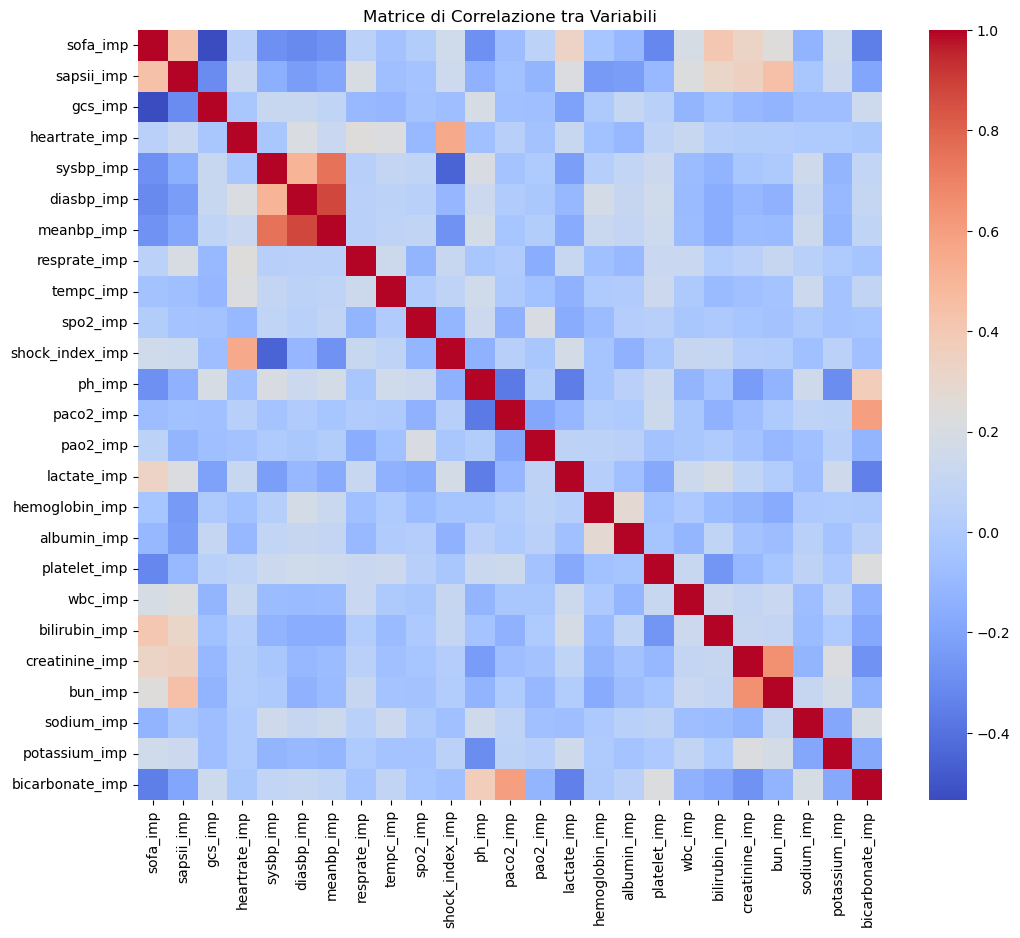

In [28]:
plt.figure(figsize=(12,10))
matrix_corr= data[imputed_var].corr(numeric_only=True)
sns.heatmap(matrix_corr, cmap='coolwarm') #annot=True,
plt.title('Matrice di Correlazione tra Variabili')
plt.show()

Let's check how many patients have a number of missing value >50 %

In [29]:
vars_to_impute=imputed_var + [ 'bmi','ibw','ards','septic_shock', 'uo'] #+ vent_vars + other_vent_vars
to_remove = ((data[vars_to_impute + demographics].isnull().groupby(data.subject_id).mean().mean(axis=1)) > .5)
print("Removing {} / {} = {} % patients due to >50 % missing values".format(to_remove.sum(), data.shape[0], 100*to_remove.sum()/data.shape[0]))
selection = data[~data.subject_id.isin(to_remove[to_remove].index)]
selected_patients = selection.drop_duplicates(subset='subject_id', keep='first')

print("Selection of {} timesteps for {} patients / mech vent events".format(selection.shape[0], selected_patients.shape[0]))

Removing 0 / 536300 = 0.0 % patients due to >50 % missing values
Selection of 536300 timesteps for 16061 patients / mech vent events


Let's impute all the missing data with the MICEForest imputer.

In [30]:
df = data[['subject_id', 'gender', 'age', 'admission_type', 'hospmort',
       'hospmort90day', 'icumort', 'bmi','ibw', 'comorb_score', 'icu_day_start','infection_at_icu_admission',
       'site_of_infection', 'admission_category', 'ards', 'septic_shock','has_dobutamine', 'has_dopamine', 'has_epinephrine',
       'has_norepinephrine', 'has_vasopressin', 'sofa_imp', 'sapsii_imp',
       'gcs_imp', 'heartrate_imp', 'sysbp_imp', 'diasbp_imp', 'meanbp_imp',
       'resprate_imp', 'tempc_imp', 'spo2_imp', 'shock_index_imp', 'ph_imp',
       'paco2_imp', 'pao2_imp', 'lactate_imp', 'hemoglobin_imp', 
       'platelet_imp', 'wbc_imp', 'creatinine_imp', 'bun_imp',
       'sodium_imp', 'potassium_imp', 'bicarbonate_imp', 'uo','prone_24h', 'crrt_24h', 'ino_24h', 'diuretic_24h', 'steroid_24h',
       'transfusion_24h', 'transfusion_type', 'neuroblock', 'opioids',
       'is_sedated', 'sedation_type', 'tidal_volume', 'peep', 'fio2', 'vent_mode',
       'vent_type', 'pao2fio2ratio', 'is_intubated', 'weaning_success']]
df.head()

,subject_id,gender,age,admission_type,hospmort,hospmort90day,icumort,bmi,ibw,comorb_score,...,is_sedated,sedation_type,tidal_volume,peep,fio2,vent_mode,vent_type,pao2fio2ratio,is_intubated,weaning_success
0,10001884,F,77,postSurgical,1,1,1,26.37,49.186,5.0,...,0,None,0.0,0.0,21.0,None,None,NaN,0,1
1,10001884,F,77,postSurgical,1,1,1,26.37,49.186,5.0,...,1,benzodiazepines,498.5,5.0,40.0,NIV,Hamilton,150.0,0,1
2,10001884,F,77,postSurgical,1,1,1,26.37,49.186,5.0,...,1,"benzodiazepines, propofol",434.0,5.0,40.0,APV (cmv),Hamilton,132.5,1,1
3,10001884,F,77,postSurgical,1,1,1,26.37,49.186,5.0,...,1,propofol,419.0,5.0,40.0,APV (cmv),Hamilton,NaN,1,1
4,10001884,F,77,postSurgical,1,1,1,26.37,49.186,5.0,...,0,None,401.0,5.0,40.0,APV (cmv),Hamilton,NaN,1,1


In [31]:
df.info()
assert df[cat + ['vent_type']].isna().sum().sum()==0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536300 entries, 0 to 536299
Data columns (total 64 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   subject_id                  536300 non-null  int64  
 1   gender                      536300 non-null  object 
 2   age                         536300 non-null  int64  
 3   admission_type              536300 non-null  object 
 4   hospmort                    536300 non-null  int64  
 5   hospmort90day               536300 non-null  int64  
 6   icumort                     536300 non-null  int64  
 7   bmi                         461556 non-null  float64
 8   ibw                         468391 non-null  float64
 9   comorb_score                536300 non-null  float64
 10  icu_day_start               536300 non-null  object 
 11  infection_at_icu_admission  536300 non-null  int64  
 12  site_of_infection           536300 non-null  object 
 13  admission_cate

In [32]:
for col in df.columns:
    if not pd.api.types.is_numeric_dtype(df[col]):
        if col!='icu_day_start':
            df[col]=df[col].astype('category')
            assert  not pd.api.types.is_numeric_dtype(df[col])

In [33]:
import miceforest as mf
kds = mf.ImputationKernel( 
    df.drop(columns=['icu_day_start', 'vent_mode']),
    random_state=1997
)

kds.mice(11)
df_imputed = kds.complete_data()

In [34]:
df_imputed
assert df_imputed.isna().sum().sum() == 0

In [35]:
df_final = pd.concat([df_imputed, df[['icu_day_start','vent_mode']]], axis=1)

Finally, we recalculate all the indices that were computed through formulas, using the imputed data.

In [36]:
df_final['pao2fio2ratio'] = round( df_final['pao2_imp']/df_final['fio2'],2)
df_final['shock_index']= round(df_final['heartrate_imp']/df_final['sysbp_imp'],2)
df_final['meanbp']= round((df_final['sysbp_imp']+2*df_final['diasbp_imp'])/3)

In [ ]:
df_final.drop(['shock_index_imp', 'meanbp_imp'], inplace=True, axis=1)
df_final.columns = df_final.columns.str.replace('_imp$', '', regex=True)

In [38]:
df_final.columns

Index(['subject_id', 'gender', 'age', 'admission_type', 'hospmort',
       'hospmort90day', 'icumort', 'bmi', 'ibw', 'comorb_score',
       'infection_at_icu_admission', 'site_of_infection', 'admission_category',
       'ards', 'septic_shock', 'has_dobutamine', 'has_dopamine',
       'has_epinephrine', 'has_norepinephrine', 'has_vasopressin', 'sofa',
       'sapsii', 'gcs', 'heartrate', 'sysbp', 'diasbp', 'resprate', 'tempc',
       'spo2', 'ph', 'paco2', 'pao2', 'lactate', 'hemoglobin', 'platelet',
       'wbc', 'creatinine', 'bun', 'sodium', 'potassium', 'bicarbonate', 'uo',
       'prone_24h', 'crrt_24h', 'ino_24h', 'diuretic_24h', 'steroid_24h',
       'transfusion_24h', 'transfusion_type', 'neuroblock', 'opioids',
       'is_sedated', 'sedation_type', 'tidal_volume', 'peep', 'fio2',
       'vent_type', 'pao2fio2ratio', 'is_intubated', 'weaning_success',
       'icu_day_start', 'vent_mode', 'shock_index', 'meanbp'],
      dtype='object')

In [50]:
df_final['ibw'] = df_final.groupby('subject_id')['ibw'].transform('mean')

In [51]:
assert (df_final.groupby('subject_id')['ibw'].nunique() == 1).all(), "Alcuni subject_id hanno più di un valore di ibw"

In [ ]:
df['adjust_tidal_volume']=df_final['tidal_volume']/df_final['ibw']
df['adjust_tidal_volume']

In [55]:
assert df_final.drop('vent_mode', axis=1).notna().all().all()
df_final.to_csv('final_data.csv', index=False)

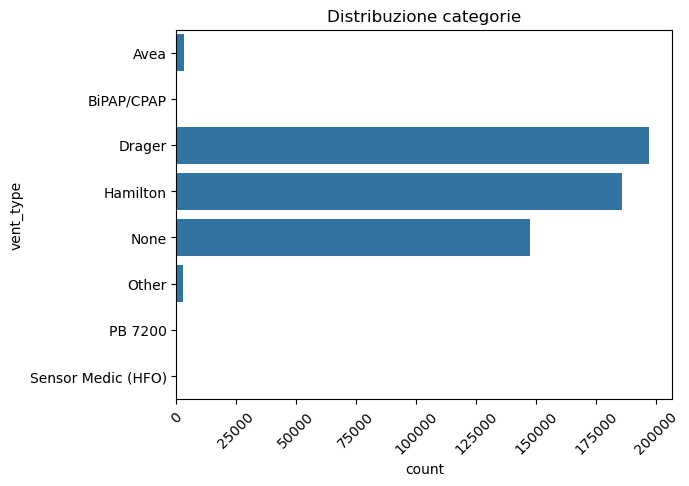

In [44]:
ax=sns.countplot(y='vent_type', data=df_final)  #[df_final['is_intubated']==1]
plt.title('Distribuzione categorie')
plt.xticks(rotation=45) 
plt.show()

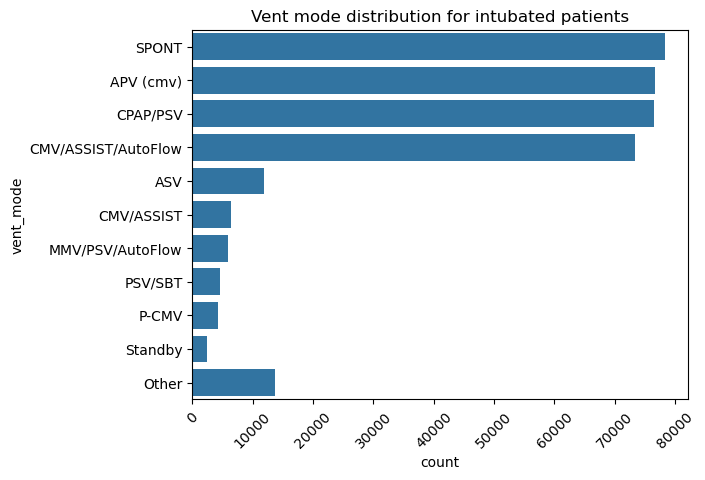

In [70]:
top10 = df_final.loc[df_final['is_intubated'] == 1, 'vent_mode'].value_counts().nlargest(10).index

# 2. Crea nuova colonna raggruppando modalità non top10 in "Other"
def group_modes(row):
    if row['is_intubated'] == 1:
        return row['vent_mode'] if row['vent_mode'] in top10 else 'Other'
    else:
        return None  # o puoi escludere questi casi dopo

df_final['vent_mode_grouped'] = df_final.apply(group_modes, axis=1)

# 3. Filtra solo i pazienti intubati (con modalità raggruppate)
df_grouped = df_final.loc[df_final['is_intubated'] == 1]

# 4. Ordina l'ordine delle barre mettendo "Other" in coda
order = list(top10) + ['Other']

# Grafico barre orizzontali con modalità raggruppate
sns.countplot(y='vent_mode_grouped', data=df_grouped, order=order)
plt.ylabel('vent_mode')
plt.xticks(rotation=45)
plt.title('Vent mode distribution for intubated patients')
plt.show()

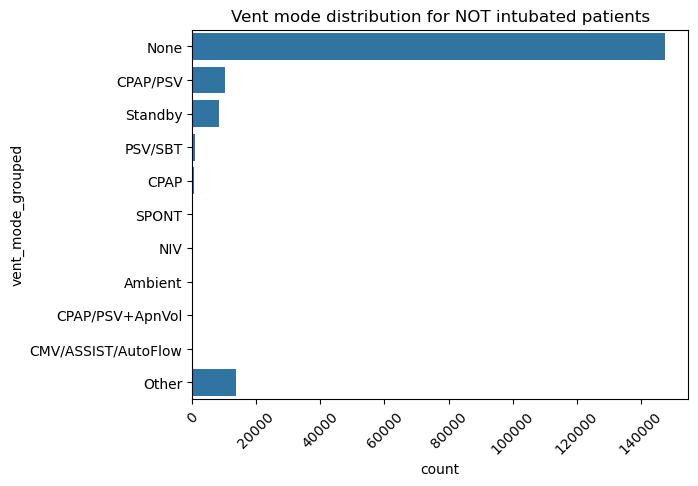

In [71]:
top10 = df_final.loc[df_final['is_intubated'] == 0, 'vent_mode'].value_counts().nlargest(10).index

# 2. Crea nuova colonna raggruppando modalità non top10 in "Other"
def group_modes(row):
    if row['is_intubated'] == 0:
        return row['vent_mode'] if row['vent_mode'] in top10 else 'Other'
    else:
        return None  # o puoi escludere questi casi dopo

df_final['vent_mode_grouped'] = df_final.apply(group_modes, axis=1)

# 3. Filtra solo i pazienti intubati (con modalità raggruppate)
df_grouped = df_final.loc[df_final['is_intubated'] == 0]

# 4. Ordina l'ordine delle barre mettendo "Other" in coda
order = list(top10) + ['Other']

# Grafico barre orizzontali con modalità raggruppate
sns.countplot(y='vent_mode_grouped', data=df_grouped, order=order)
plt.xticks(rotation=45)
plt.title('Vent mode distribution for NOT intubated patients')
plt.show()

##  final consideration

In [80]:
patients = df_final.drop_duplicates('subject_id', keep='first')
print("{:<30} {}".format("Included patients", patients.subject_id.nunique()))
print("{:<30} {:.2f} +- ({:.2f}-{:.2f})".format(
    "Age, years median (q1-q3)",
    patients.age.median(),
    patients.age.quantile(.25),
    patients.age.quantile(.75)
))
print("{:<30} {:.2f} ± {:.2f}".format(
    "BMI mean ±std",
    patients.bmi.mean(),
    patients.bmi.std()
))
gender_counts = patients.gender.value_counts
print("{:<30} {} ({:.2f}%)".format("Female", (patients.gender == 'F').sum(), 100*(patients.gender == 'F').sum() / patients.shape[0]))
print("{:<30} {} ({:.2f}%)".format("Male", (patients.gender == 'M').sum(), 100*(patients.gender == 'M').sum() / patients.shape[0]))
print("{:<30} {:.2f}%".format("90-day mortality", (patients.hospmort90day == 1).sum() / patients.shape[0] / 0.01))
print("{:<30} {:.2f}%".format("Hosp mortality", (patients.hospmort == 1).sum() / patients.shape[0] / 0.01))
#print("{:<30} {:.2f} ({:.2f}-{:.2f})".format("LOS ICU median (q1-q3)", patients.los_icu_day.median(), patients.los_icu_day.quantile(.25), patients.los_icu_day.quantile(.75)))
#print("{:<30} {:.2f} ({:.2f}-{:.2f})".format("LOS hosp median (q1-q3)", patients.los_hospital_day.median(), patients.los_hospital_day.quantile(.25), patients.los_hospital_day.quantile(.75)))
print("{:<30} {:.1f} ±{:.2f}".format("PEEP cmH2O mean ± std", df_final.peep.mean(), df_final.peep.std()))
print("{:<30} {:.2f} ±{:.2f}".format("FiO2, % mean ± std", df_final.fio2.mean(), df_final.fio2.std()))
print("{:<30} {:.2f} ±{:.2f}".format(
    "Comorbidity mean ± std",
    df_final.comorb_score.mean(),
    df_final.comorb_score.std()
))
print("{:<30} {:.2f} ±{:.2f}".format(
    "SOFA adm. mean ± std",
    df_final.sofa.mean(),
    df_final.sofa.std()
))

Included patients              16061
Age, years median (q1-q3)      66.00 +- (55.00-76.00)
BMI mean ±std                  28.97 ± 6.83
Female                         6113 (38.06%)
Male                           9948 (61.94%)
90-day mortality               22.43%
Hosp mortality                 17.41%
PEEP cmH2O mean ± std          5.3 ±4.33
FiO2, % mean ± std             41.26 ±16.92
Comorbidity mean ± std         4.74 ±2.86
SOFA adm. mean ± std           8.27 ±4.73


Numero ottimale di cluster (knee): 7


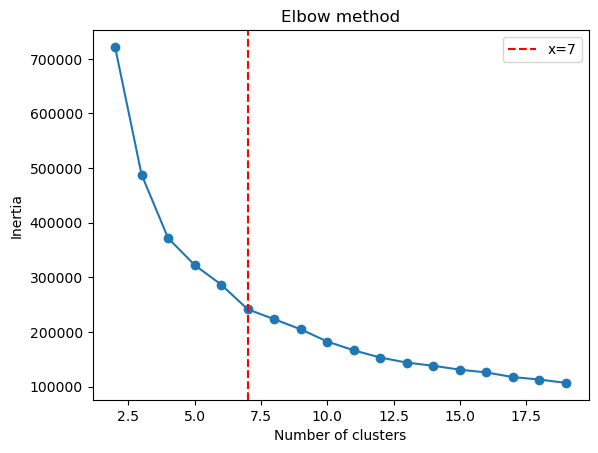

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from kneed import KneeLocator

scaler = StandardScaler()
X = scaler.fit_transform(df_final[vent_vars])

inertias = []
ks = range(2, 20)
for k in ks:
    km = KMeans(n_clusters=k, random_state=1997)
    km.fit(X)
    inertias.append(km.inertia_)

knee = KneeLocator(
    ks,
    inertias,
    curve="convex",
    direction="decreasing"
)

print("Numero ottimale di cluster (knee):", knee.knee)
plt.plot(ks, inertias, 'o-')
plt.axvline(x=knee.knee, color='red', linestyle='--', label=f'x={knee.knee}')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.legend()
plt.show()